# Factor Model: Alpha Signal Generation

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr
import warnings
import statsmodels.api as sm
warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd().parent / "data"

PROJECT_ROOT = Path(".").resolve().parent   
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

from src.config import TRAIN_START, TRAIN_END, TEST_START, TEST_END
from src.utils import calculate_factor_spread, train_test_split

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False, 
    "axes.spines.right": False,
    "axes.grid": True, 
    "grid.alpha": 0.3,
    "figure.titlesize": 14,
    "axes.titlesize": 12,
    "legend.fontsize": 9
})

In [2]:
# -------------------- Load ETF data ─--------------------
prices      = pd.read_parquet(DATA_DIR / "prices.parquet")
log_ret   = pd.read_parquet(DATA_DIR / "log_returns.parquet")
monthly_ret = pd.read_parquet(DATA_DIR / "monthly_returns.parquet")
volumes     = pd.read_parquet(DATA_DIR / "volumes.parquet")
 
TICKERS = prices.columns.tolist()
print(f"Loaded {len(TICKERS)} ETFs | {log_ret.shape[0]} daily obs | {monthly_ret.shape[0]} monthly obs")

Loaded 31 ETFs | 4110 daily obs | 196 monthly obs


## Factor Signals

In [3]:
rf = log_ret["BIL"] if "BIL" in log_ret.columns else 0
mkt_full = log_ret.mean(axis=1) - rf

shares_outstanding = {}
for ticker in TICKERS:
    # Fetch the info object for each ETF
    info = yf.Ticker(ticker).info
    shares = info.get("totalAssets", 0)/ info.get("navPrice") 
    shares_outstanding[ticker] = shares

shares_series = pd.Series(shares_outstanding).replace(0, np.nan)
mkt_cap_proxy = prices * shares_series

smb_full = calculate_factor_spread(mkt_cap_proxy.shift(1), log_ret, inverse=True)

value_signal = (prices.rolling(252*3).max() / prices) - 1
hml_full = calculate_factor_spread(value_signal.shift(1), log_ret, inverse=False)

mom_signal = prices.shift(21).pct_change(252-21)
wml_full = calculate_factor_spread(mom_signal.shift(1), log_ret, inverse=False)

ff3 = pd.DataFrame({"MKT": mkt_full, "SMB": smb_full, "HML": hml_full}).dropna()
ff4 = ff3.assign(WML=wml_full).dropna()

## Train/Test Split

In [ ]:
# Training set
mkt_full_train, mkt_full_test = train_test_split(mkt_full, TRAIN_START, TRAIN_END, TEST_START, TEST_END)
smb_train, smb_test = train_test_split(smb_full, TRAIN_START, TRAIN_END, TEST_START, TEST_END)
hml_train, hml_test = train_test_split(hml_full, TRAIN_START, TRAIN_END, TEST_START, TEST_END)
wml_train, wml_test = train_test_split(wml_full, TRAIN_START, TRAIN_END, TEST_START, TEST_END)

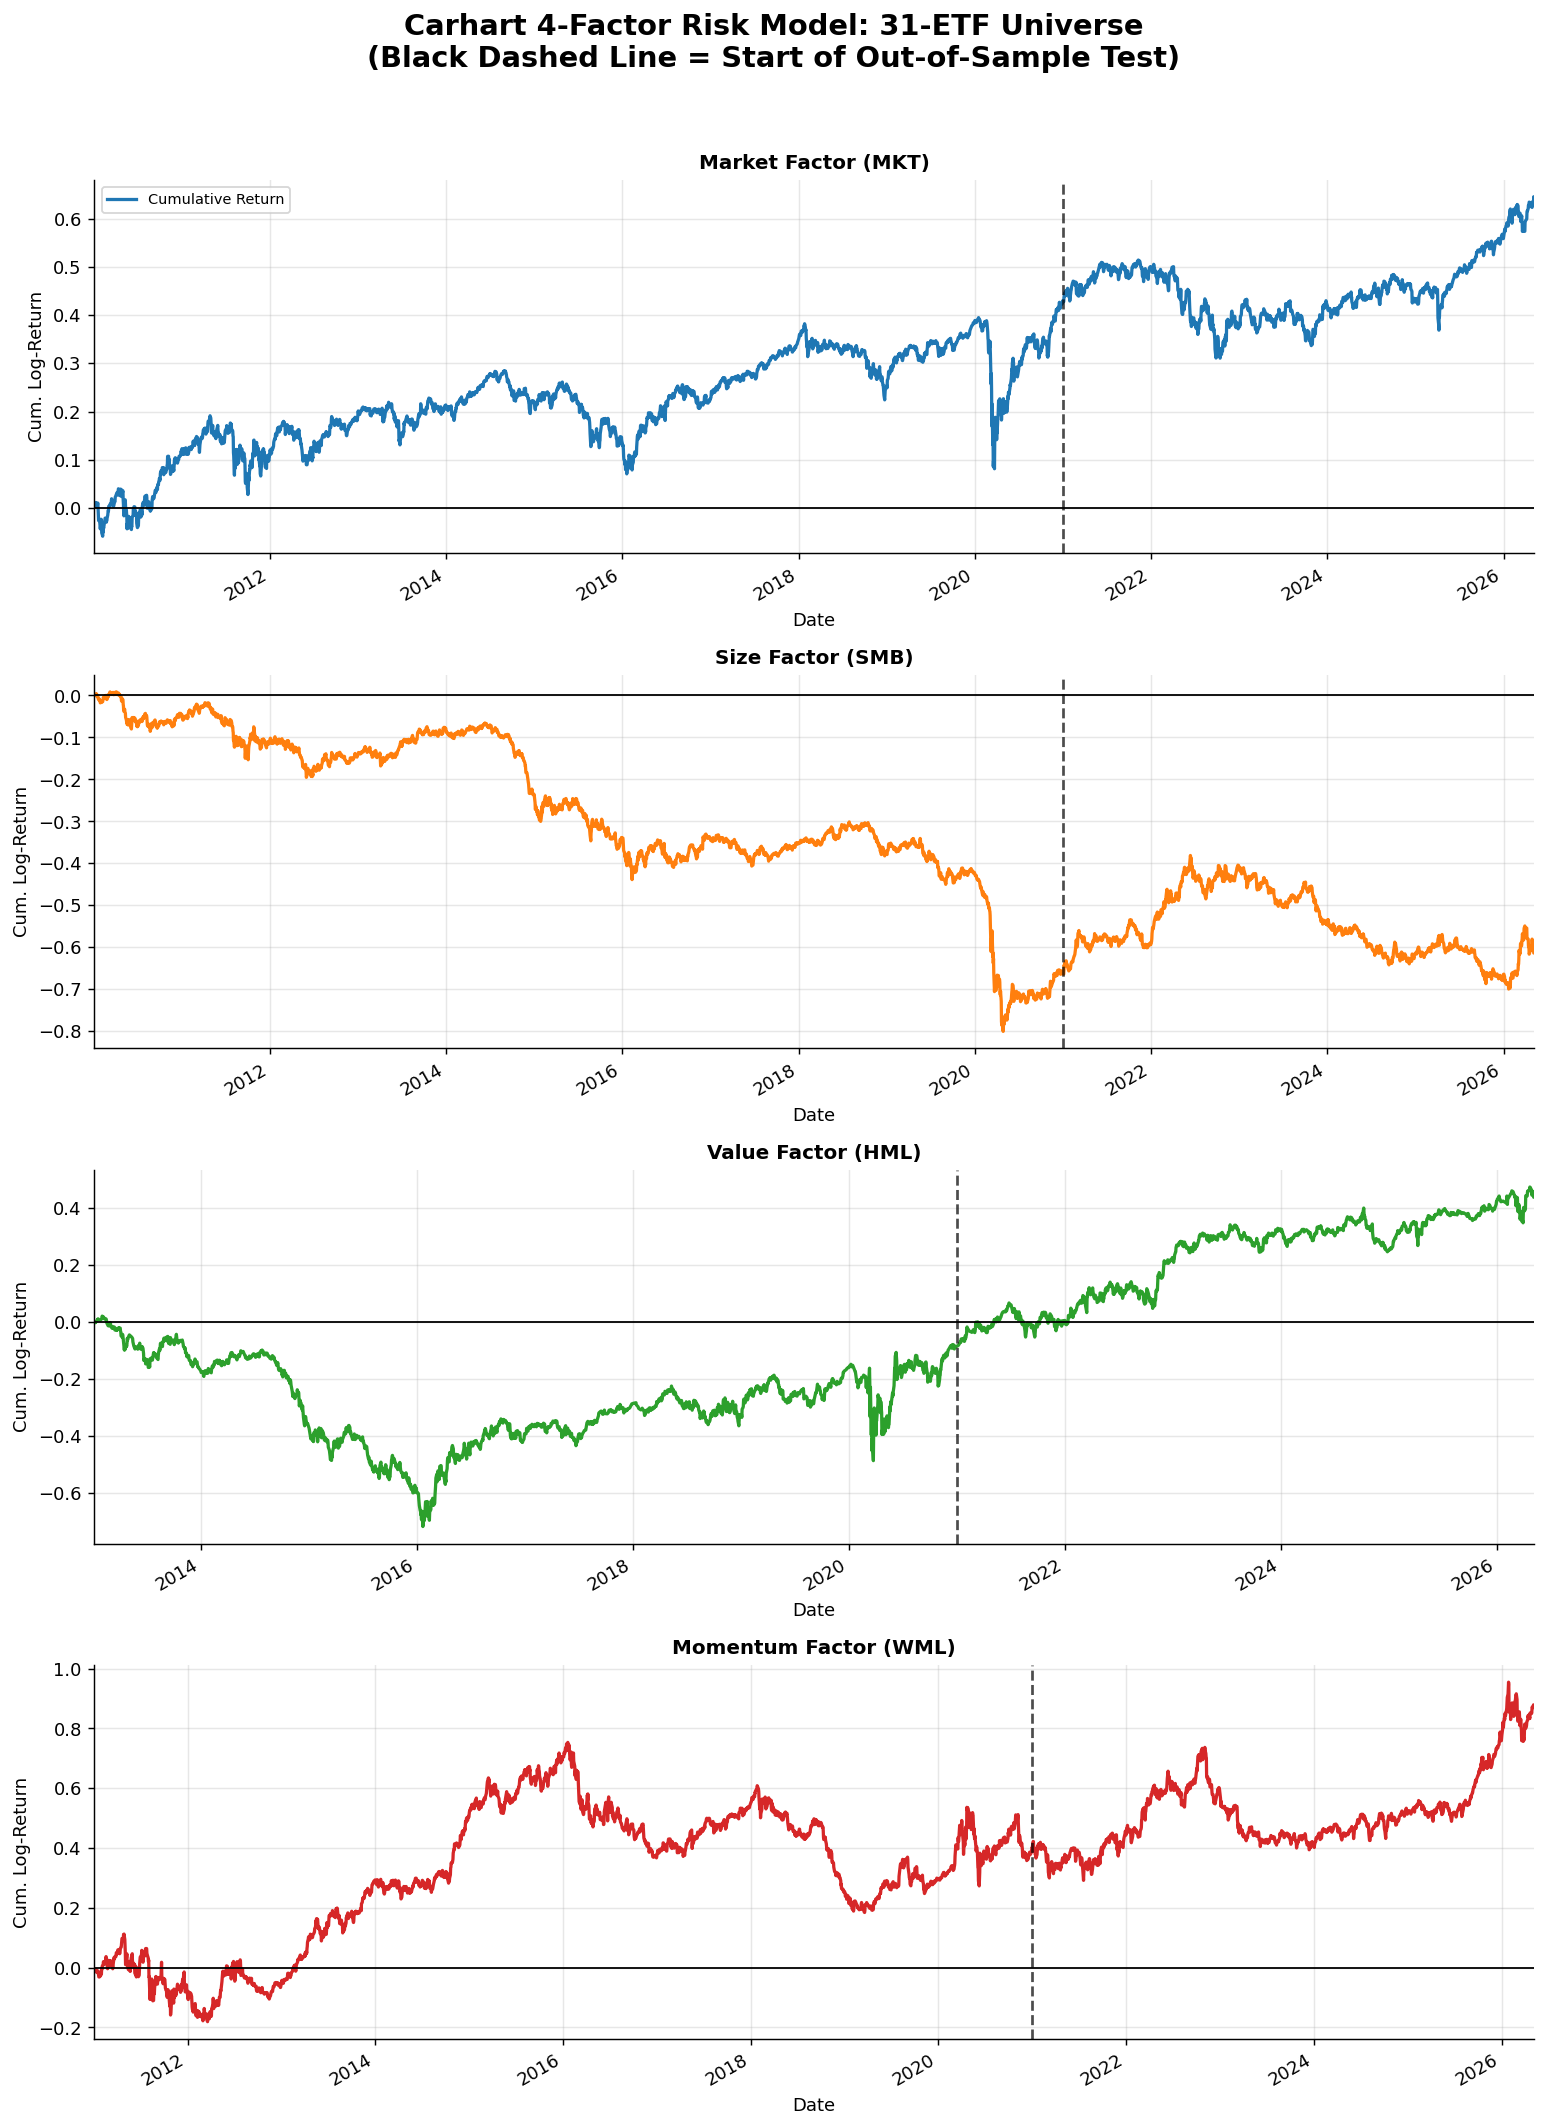

In [5]:
# -------------------- Plotting --------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 16))

factors = [
    (mkt_full, "Market Factor (MKT)", "#1f77b4"),
    (smb_full, "Size Factor (SMB)", "#ff7f0e"),
    (hml_full, "Value Factor (HML)", "#2ca02c"),
    (wml_full, "Momentum Factor (WML)", "#d62728")
]

for i, (data, title, col) in enumerate(factors):
    ax = axes[i]
    clean_data = data.dropna()
    if clean_data.empty: continue 
    
    cum_ret = clean_data.cumsum()
    cum_ret.plot(ax=ax, color=col, lw=1.8, label="Cumulative Return")
    
    ax.axvline(x=TRAIN_END, color='black', lw=1.5, ls='--', alpha=0.7, zorder=5)

    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.axhline(0, color='black', lw=1.0)
    ax.set_ylabel("Cum. Log-Return")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(cum_ret.index.min(), cum_ret.index.max())

axes[0].legend(loc='upper left', fontsize=8)
plt.suptitle("Carhart 4-Factor Risk Model: 31-ETF Universe\n(Black Dashed Line = Start of Out-of-Sample Test)", 
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig(DATA_DIR / "03_Four_Factors_models.png", bbox_inches="tight", dpi=200)
plt.show()

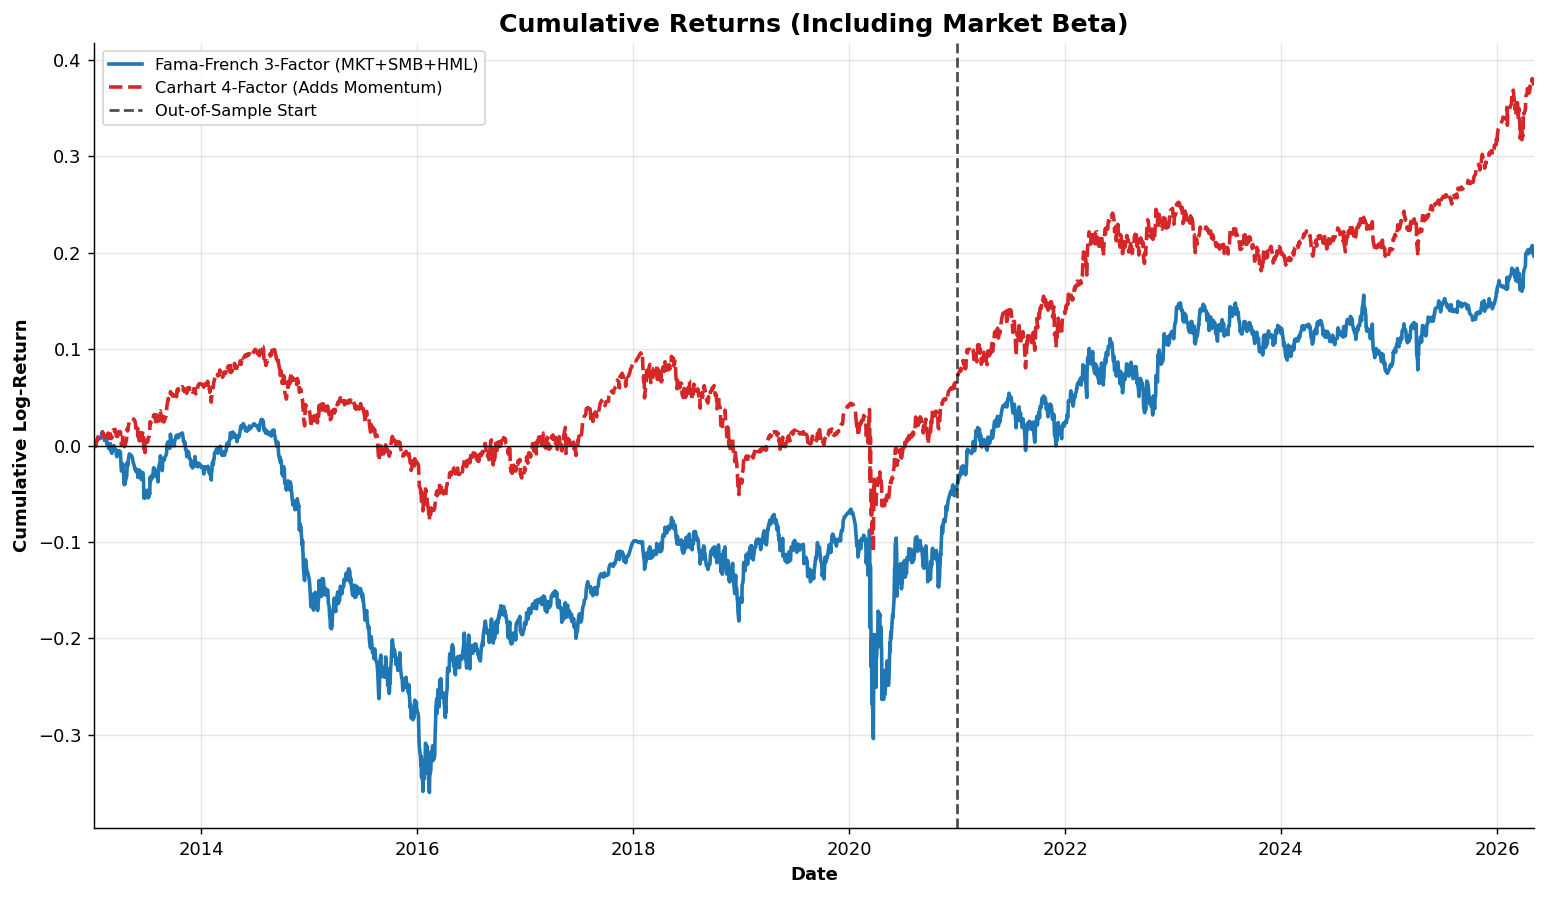

In [6]:
# Calculate the equal-weighted cumulative return of the factors in each model
ff3_total = ff3.mean(axis=1).cumsum()
ff4_total = ff4.mean(axis=1).cumsum()

plt.figure(figsize=(12, 7))

# Plot the two models
plt.plot(ff3_total, label="Fama-French 3-Factor (MKT+SMB+HML)", color="#1f77b4", lw=2)
plt.plot(ff4_total, label="Carhart 4-Factor (Adds Momentum)", color="#d62728", lw=2, linestyle="--")

plt.title("Cumulative Returns (Including Market Beta)", fontsize=14, fontweight="bold")
plt.ylabel("Cumulative Log-Return", fontweight="bold")
plt.xlabel("Date", fontweight="bold")

plt.xlim(ff4.index.min(), ff4.index.max())
plt.axvline(x=pd.to_datetime(TRAIN_END), color='black', lw=1.5, ls='--', alpha=0.7, label="Out-of-Sample Start")

plt.axhline(0, color="black", lw=0.8, ls="-")
plt.legend(loc="upper left", frameon=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "04_alpha_comparision_with_mkt.png", dpi=200, bbox_inches="tight")
plt.show()

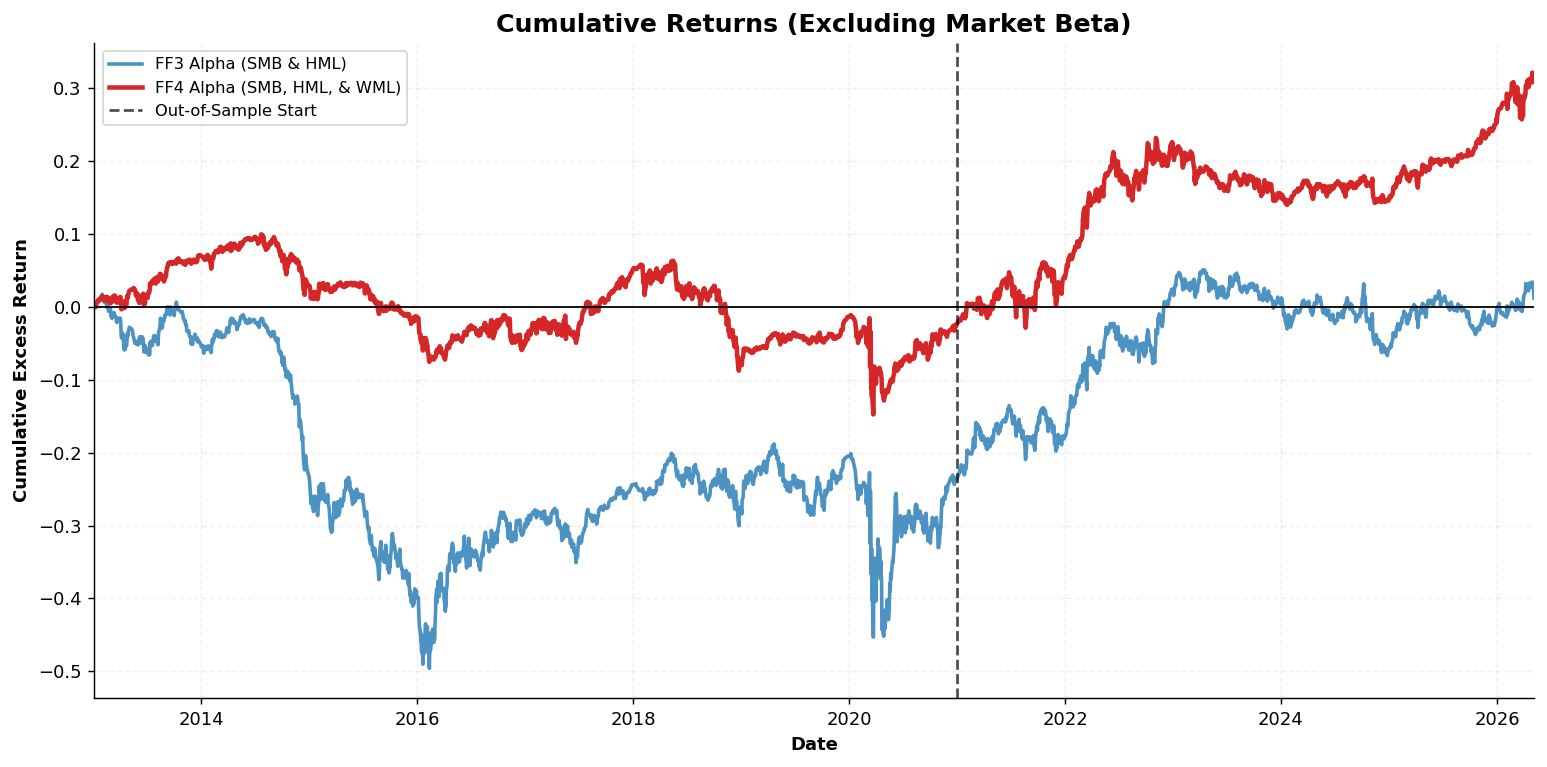

In [7]:
ff3_alpha = ff3[["SMB", "HML"]].mean(axis=1).cumsum()
ff4_alpha = ff4[["SMB", "HML", "WML"]].mean(axis=1).cumsum()

start_date = max(ff3_alpha.index.min(), ff4_alpha.index.min())
ff3_plot = ff3_alpha.loc[start_date:]
ff4_plot = ff4_alpha.loc[start_date:]
ff3_plot = ff3_plot - ff3_plot.iloc[0]
ff4_plot = ff4_plot - ff4_plot.iloc[0]

plt.figure(figsize=(12, 6))

# Plot
plt.plot(ff3_plot, label="FF3 Alpha (SMB & HML)", color="#1f77b4", lw=2, alpha=0.8)
plt.plot(ff4_plot, label="FF4 Alpha (SMB, HML, & WML)", color="#d62728", lw=2.5)
plt.title("Cumulative Returns (Excluding Market Beta)", fontsize=14, fontweight="bold")
plt.ylabel("Cumulative Excess Return", fontweight="bold")
plt.xlabel("Date", fontweight="bold")
plt.xlim(ff4.index.min(), ff4.index.max())
plt.axhline(0, color="black", lw=1, ls="-")
plt.grid(True, alpha=0.2, linestyle="--")
plt.axvline(x=pd.to_datetime(TRAIN_END), color='black', lw=1.5, ls='--', alpha=0.7, label="Out-of-Sample Start")
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig(DATA_DIR / "05_alpha_comparison_without_mkt.png", dpi=200, bbox_inches="tight")
plt.show()